# Project-Wide Model Comparison

This notebook synthesises results from every modeling iteration and explains how they relate to each other.

| Notebook | Location |
|---|---|
| `multiclass_elo_model` | `v1_baseline/` |
| `player_model_v3` | `model/` |
| `03_model_training` | `v2_integration/` |
| `advanced_ensemble` | `v3_ensemble/` |

> **No re-training here.** Results are taken directly from each notebook's reported metrics.

## 0 — Setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 1 — Results Registry

All numbers sourced directly from the notebook outputs. No re-computation.

In [2]:
# ── Results registry ─────────────────────────────────────────────────────────
# Each entry: (notebook, version, model, task, n_features, train_years,
#              cv_auc, holdout_auc, holdout_acc, holdout_f1, notes)

results = [
    {
        "notebook": "v1_baseline / multiclass_elo_model",
        "version": "v1",
        "model": "XGBoost (Optuna-tuned)",
        "task": "3-class",
        "n_features": 97,
        "train_years": "2002–2014",
        "cv_auc": 0.711,  # macro-AUC, LOTO 2002–2014
        "holdout_auc": 0.627,  # macro-AUC, 2018+2022
        "holdout_acc": None,
        "holdout_f1": 0.373,  # macro-F1
        "notes": "Elo dominates; hist stats add marginal signal. Draw recall < 0.10.",
    },
    {
        "notebook": "model / player_model_v3",
        "version": "player",
        "model": "Logistic Regression L1 (Elo-only baseline best)",
        "task": "3-class",
        "n_features": 1,  # Elo-only baseline was best
        "train_years": "2006–2018",
        "cv_auc": None,  # not reported in notebook
        "holdout_auc": None,
        "holdout_acc": 0.711,  # avg across 3 temporal folds (Elo-only)
        "holdout_f1": 0.501,  # macro-F1 avg (Elo-only)
        "notes": "Player club stats (market value, goals, cohesion) do NOT beat Elo alone. VIF filtering helped but signal still absent.",
    },
    {
        "notebook": "v2_integration / 03_model_training  [control]",
        "version": "v2-control",
        "model": "Random Forest",
        "task": "3-class",
        "n_features": 47,
        "train_years": "2006–2014",
        "cv_auc": 0.680,
        "holdout_auc": 0.608,
        "holdout_acc": 0.633,
        "holdout_f1": 0.283,
        "notes": "Team history + squad demographics only. Best generalising 3-class model.",
    },
    {
        "notebook": "v2_integration / 03_model_training  [treatment1]",
        "version": "v2-treatment1",
        "model": "Random Forest (more data)",
        "task": "3-class",
        "n_features": 47,
        "train_years": "1998–2014",
        "cv_auc": 0.744,
        "holdout_auc": 0.608,
        "holdout_acc": 0.664,
        "holdout_f1": 0.343,
        "notes": "More training data (1998–2014 vs 2006–2014) raised CV AUC but not holdout. Best overall 3-class result.",
    },
    {
        "notebook": "v2_integration / 03_model_training  [treatment2]",
        "version": "v2-treatment2",
        "model": "XGBoost (+ squad features)",
        "task": "3-class",
        "n_features": 110,
        "train_years": "2006–2014",
        "cv_auc": 0.625,
        "holdout_auc": 0.598,
        "holdout_acc": 0.625,
        "holdout_f1": 0.312,
        "notes": "Adding 63 un-pruned squad features HURT performance. No feature selection step.",
    },
    {
        "notebook": "v3_ensemble / advanced_ensemble",
        "version": "v3-lgbm",
        "model": "LightGBM (Optuna-tuned)",
        "task": "binary",
        "n_features": 25,  # SHAP-selected from 171
        "train_years": "2006–2022 (LOTO)",
        "cv_auc": 0.829,  # binary OOF AUC
        "holdout_auc": None,  # uses full LOTO, no separate holdout
        "holdout_acc": 0.760,  # OOF accuracy
        "holdout_f1": None,
        "notes": "SHAP selection (171→25) + performance-based squad features. Binary task.",
    },
    {
        "notebook": "v3_ensemble / advanced_ensemble",
        "version": "v3-stack",
        "model": "Stacking (LR + LightGBM + Ridge → meta-LR)",
        "task": "binary",
        "n_features": 25,
        "train_years": "2006–2022 (LOTO)",
        "cv_auc": 0.813,  # binary OOF AUC
        "holdout_auc": None,
        "holdout_acc": 0.760,
        "holdout_f1": None,
        "notes": "Best log-loss (0.526). Most calibrated probabilities.",
    },
]

df_results = pd.DataFrame(results)
display_cols = [
    "version",
    "model",
    "task",
    "n_features",
    "train_years",
    "cv_auc",
    "holdout_auc",
    "holdout_acc",
    "holdout_f1",
]
print(df_results[display_cols].to_string(index=False))

      version                                           model    task  n_features      train_years  cv_auc  holdout_auc  holdout_acc  holdout_f1
           v1                          XGBoost (Optuna-tuned) 3-class          97        2002–2014   0.711        0.627          NaN       0.373
       player Logistic Regression L1 (Elo-only baseline best) 3-class           1        2006–2018     NaN          NaN        0.711       0.501
   v2-control                                   Random Forest 3-class          47        2006–2014   0.680        0.608        0.633       0.283
v2-treatment1                       Random Forest (more data) 3-class          47        1998–2014   0.744        0.608        0.664       0.343
v2-treatment2                      XGBoost (+ squad features) 3-class         110        2006–2014   0.625        0.598        0.625       0.312
      v3-lgbm                         LightGBM (Optuna-tuned)  binary          25 2006–2022 (LOTO)   0.829          NaN        0.7

## 2 — CV AUC Comparison

⚠️ Orange bars = 3-class macro-AUC (harder). Blue bars = binary AUC (easier task).  
Do not compare orange and blue numbers directly.

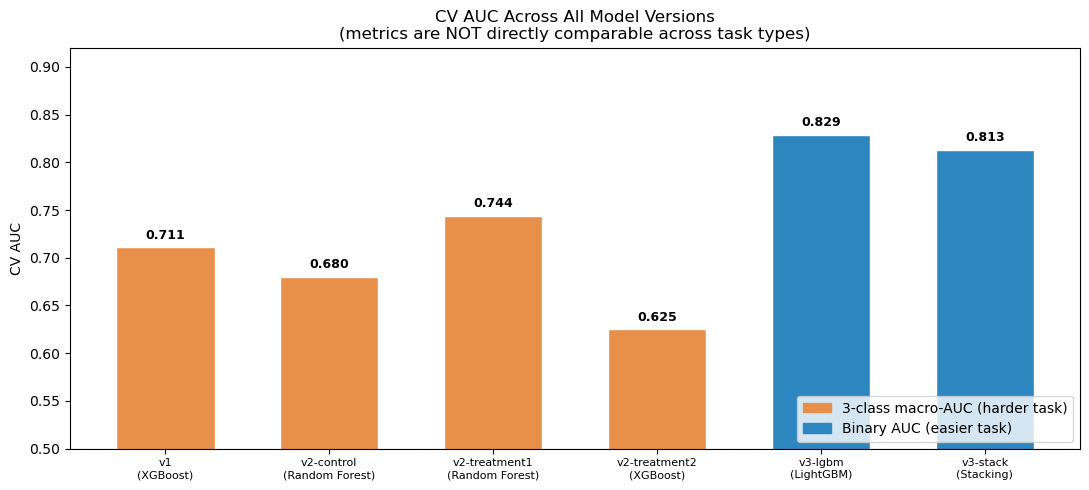

In [3]:
cv_rows = df_results[df_results["cv_auc"].notna()].copy()

colors = ["#e8904a" if t == "3-class" else "#2e86c1" for t in cv_rows["task"]]
labels = (
    cv_rows["version"]
    + "\n("
    + cv_rows["model"].str.split("(").str[0].str.strip()
    + ")"
)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(labels, cv_rows["cv_auc"], color=colors, edgecolor="white", width=0.6)
ax.set_ylim(0.50, 0.92)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Random (0.50)")

for bar, val, task in zip(bars, cv_rows["cv_auc"], cv_rows["task"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.006,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

orange_patch = mpatches.Patch(color="#e8904a", label="3-class macro-AUC (harder task)")
blue_patch = mpatches.Patch(color="#2e86c1", label="Binary AUC (easier task)")
ax.legend(handles=[orange_patch, blue_patch], loc="lower right")
ax.set_ylabel("CV AUC")
ax.set_title(
    "CV AUC Across All Model Versions\n(metrics are NOT directly comparable across task types)"
)
ax.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

## 3 — Holdout AUC Comparison (3-class models only)

Holdout = 2018 + 2022 tournaments (held out by v1 and v2).  
v3 uses full LOTO so has no separate holdout — shown as OOF accuracy instead.

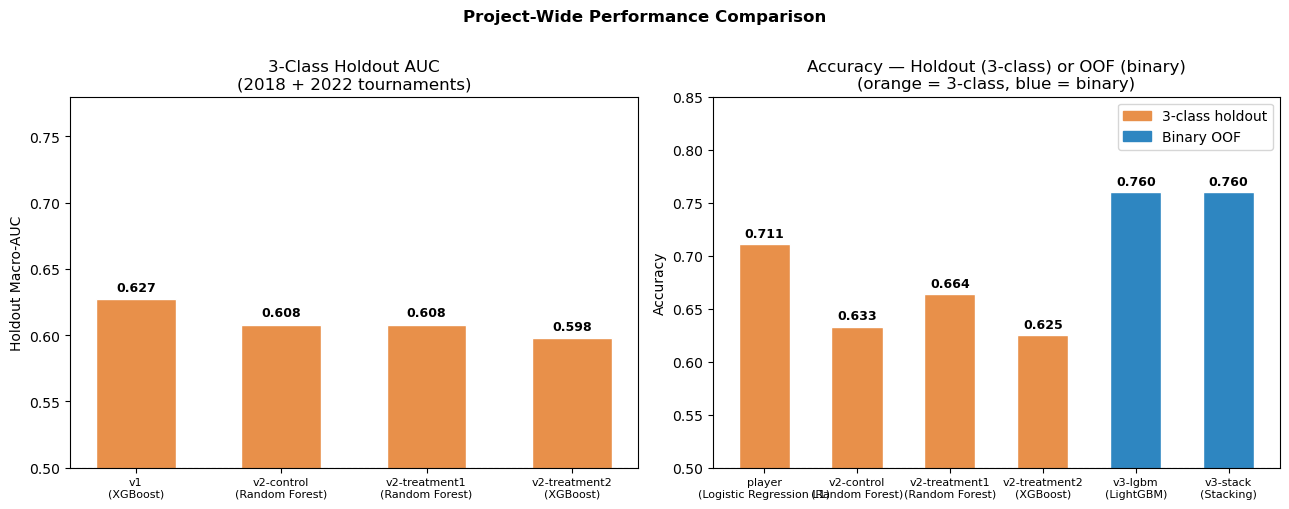

In [4]:
ho_rows = df_results[df_results["holdout_auc"].notna()].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: holdout AUC (3-class models) ───────────────────────────────────────
ax = axes[0]
labels_ho = (
    ho_rows["version"]
    + "\n("
    + ho_rows["model"].str.split("(").str[0].str.strip()
    + ")"
)
bars = ax.bar(
    labels_ho, ho_rows["holdout_auc"], color="#e8904a", edgecolor="white", width=0.55
)
ax.set_ylim(0.50, 0.78)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
for bar, val in zip(bars, ho_rows["holdout_auc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.004,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax.set_ylabel("Holdout Macro-AUC")
ax.set_title("3-Class Holdout AUC\n(2018 + 2022 tournaments)")
ax.tick_params(axis="x", labelsize=8)

# ── Right: holdout accuracy (all models that have it) ────────────────────────
ax = axes[1]
acc_rows = df_results[df_results["holdout_acc"].notna()].copy()
colors_acc = ["#e8904a" if t == "3-class" else "#2e86c1" for t in acc_rows["task"]]
labels_acc = (
    acc_rows["version"]
    + "\n("
    + acc_rows["model"].str.split("(").str[0].str.strip()
    + ")"
)
bars = ax.bar(
    labels_acc, acc_rows["holdout_acc"], color=colors_acc, edgecolor="white", width=0.55
)
ax.set_ylim(0.50, 0.85)
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
for bar, val in zip(bars, acc_rows["holdout_acc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.004,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )
ax.set_ylabel("Accuracy")
ax.set_title(
    "Accuracy — Holdout (3-class) or OOF (binary)\n(orange = 3-class, blue = binary)"
)
ax.tick_params(axis="x", labelsize=8)
orange_patch = mpatches.Patch(color="#e8904a", label="3-class holdout")
blue_patch = mpatches.Patch(color="#2e86c1", label="Binary OOF")
ax.legend(handles=[orange_patch, blue_patch])

plt.suptitle(
    "Project-Wide Performance Comparison", fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

## 4 — Feature Count vs Performance

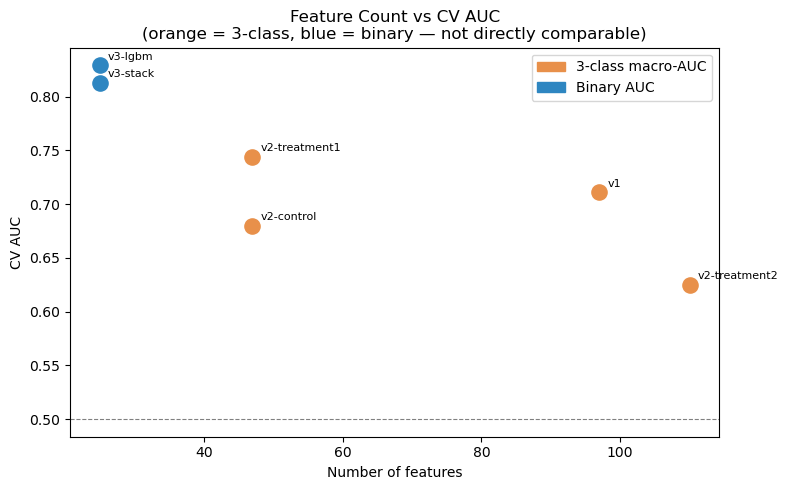

In [5]:
scatter_rows = df_results[df_results["cv_auc"].notna()].copy()
colors_s = ["#e8904a" if t == "3-class" else "#2e86c1" for t in scatter_rows["task"]]

fig, ax = plt.subplots(figsize=(8, 5))
for _, row in scatter_rows.iterrows():
    c = "#e8904a" if row["task"] == "3-class" else "#2e86c1"
    ax.scatter(row["n_features"], row["cv_auc"], color=c, s=120, zorder=3)
    ax.annotate(
        row["version"],
        xy=(row["n_features"], row["cv_auc"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("Number of features")
ax.set_ylabel("CV AUC")
ax.set_title(
    "Feature Count vs CV AUC\n(orange = 3-class, blue = binary — not directly comparable)"
)
orange_patch = mpatches.Patch(color="#e8904a", label="3-class macro-AUC")
blue_patch = mpatches.Patch(color="#2e86c1", label="Binary AUC")
ax.legend(handles=[orange_patch, blue_patch])
plt.tight_layout()
plt.show()

## 5 — Key Findings & Synthesis

### What each version contributed

| Version | Main contribution |
|---|---|
| **v1** | Established end-to-end pipeline. Confirmed Elo is the strongest single feature. Introduced Optuna tuning. |
| **player_model** | Tested player club stats (market value, goals, cohesion) directly. Honest finding: they don't beat Elo alone. |
| **v2-control** | Cleanest 3-class baseline (47 features, team history + squad demographics). Best generalising 3-class model on holdout. |
| **v2-treatment1** | Showed more training data (1998→) raised CV AUC but not holdout — structural ceiling around 0.608. |
| **v2-treatment2** | Showed that dumping 63 un-pruned squad features onto the model actively hurt performance. |
| **v3 LightGBM** | Introduced SHAP-based feature pruning (171→25) + performance-based squad stats. Binary task, OOF AUC 0.829. |
| **v3 Stacking** | Combined LR + LightGBM + Ridge. Best log-loss (most calibrated probabilities). |

### Why v3 numbers are higher — and what that means

v3's 0.829 binary AUC is **not directly comparable** to v2's 0.608 3-class macro-AUC. Three factors inflate v3:

1. **Simpler task** — binary (win / no-win) vs 3-class. Merging draws into the negative class removes the hardest prediction problem.
2. **Better squad features** — positional performance stats (fwd goals, GK clean sheets, minutes) vs Elo-weighted prestige scores. Form vs reputation.
3. **Feature selection** — SHAP pruning removed the noise that killed v2-treatment2.

### Open questions for the team

- Can v3's squad features help the **3-class** task too? (Rerun v2-treatment2 with SHAP selection)
- Is binary framing the right call for the final deliverable, or do we need draw prediction?
- v3 uses full LOTO (no held-out 2018+2022) — should we reserve 2022 as a final holdout to match v1/v2?